# **COVID-19 Data Analysis**

This case study analyzes COVID-19 confirmed cases, deaths, and recoveries using Pandas, Matplotlib, and Seaborn.

The analysis covers data loading, exploration, cleaning, transformation, dataset merging, and visualization to understand the progression of the pandemic across countries and over time.

# **Data Loading**
The confirmed cases, deaths, and recoveries datasets are loaded from the provided Excel workbook for further analysis.

In [1]:
import pandas as pd

In [2]:
c = pd.read_excel("/content/covid_19_dataset-1718175635.xlsx",sheet_name = "covid_19_confirmed_v1")

In [3]:
r = pd.read_excel("/content/covid_19_dataset-1718175635.xlsx",sheet_name = "covid_19_recovered_v1")

In [4]:
d = pd.read_excel("/content/covid_19_dataset-1718175635.xlsx",sheet_name = "covid_19_deaths_v1")

## **Data Exploration**

The dataset is explored to understand its structure, dimensions, data types, and the format of the COVID-19 case records.

The confirmed cases dataset is examined first, followed by transformation of the date columns into a format suitable for time-series analysis.

In [5]:
c.head(3)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456


In [6]:
date_columns = c.columns[4:]

correct_dates = pd.date_range(
    start="2020-01-22",
    periods=len(date_columns),
    freq="D"
)

# Rename the date columns
c.columns = (
    list(c.columns[:4]) +
    list(correct_dates)
)

In [7]:
df_c = pd.melt(c,id_vars=["Province/State", "Country/Region", "Lat", "Long"],var_name="Date",value_name="C_cases")

In [8]:
df_c.head(3)

,Province/State,Country/Region,Lat,Long,Date,C_cases
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22 00:00:00,0
1,NaN,Albania,41.15330,20.168300,2020-01-22 00:00:00,0
2,NaN,Algeria,28.03390,1.659600,2020-01-22 00:00:00,0


In [9]:
df_c.shape

(136344, 6)

In [10]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136344 entries, 0 to 136343
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Province/State  42484 non-null   object 
 1   Country/Region  136344 non-null  object 
 2   Lat             135356 non-null  float64
 3   Long            135356 non-null  float64
 4   Date            136344 non-null  object 
 5   C_cases         136344 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 6.2+ MB


In [11]:
df_c = df_c.sort_values(by='Country/Region')

In [12]:
df_c['Date'] = pd.to_datetime(df_c['Date'])
df_c = df_c.sort_values(by='Date')

## **Data Cleaning and Preparation**

Missing values in the `Province/State` column are replaced with `"All Provinces"` to provide a consistent label for records where province/state information is unavailable.

This makes the dataset easier to group, filter, and interpret during country-level and province-level analysis.

In [13]:
df_c["Province/State"] = df_c["Province/State"].fillna("All Provinces")

In [14]:
df_c.isnull().sum()

,0
Province/State,0
Country/Region,0
Lat,988
Long,988
Date,0
C_cases,0


## **Missing Value Handling**

The dataset contains 988 missing values each in the **`Lat`** and **`Long`** columns. Since these geographical coordinates are not required for the analysis in this case study, the missing values were retained as they are.

The **`Date`** and **`C_cases`** columns contain no missing values, so no imputation was required for the time-series COVID-19 case data.

## **Confirmed Cases Over Time: Top 3 Countries**

The three countries with the highest cumulative confirmed cases on the latest available date are identified and their confirmed case trends are compared over time.

In [15]:
top_countries = df_c[df_c["Date"] == df_c["Date"].max()].groupby("Country/Region")["C_cases"].sum().sort_values(ascending=False).head(3).index

In [16]:
top_countries

Index(['US', 'India', 'Brazil'], dtype='object', name='Country/Region')

In [17]:
top3_countries = df_c[df_c["Country/Region"].isin(top_countries)].copy()

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

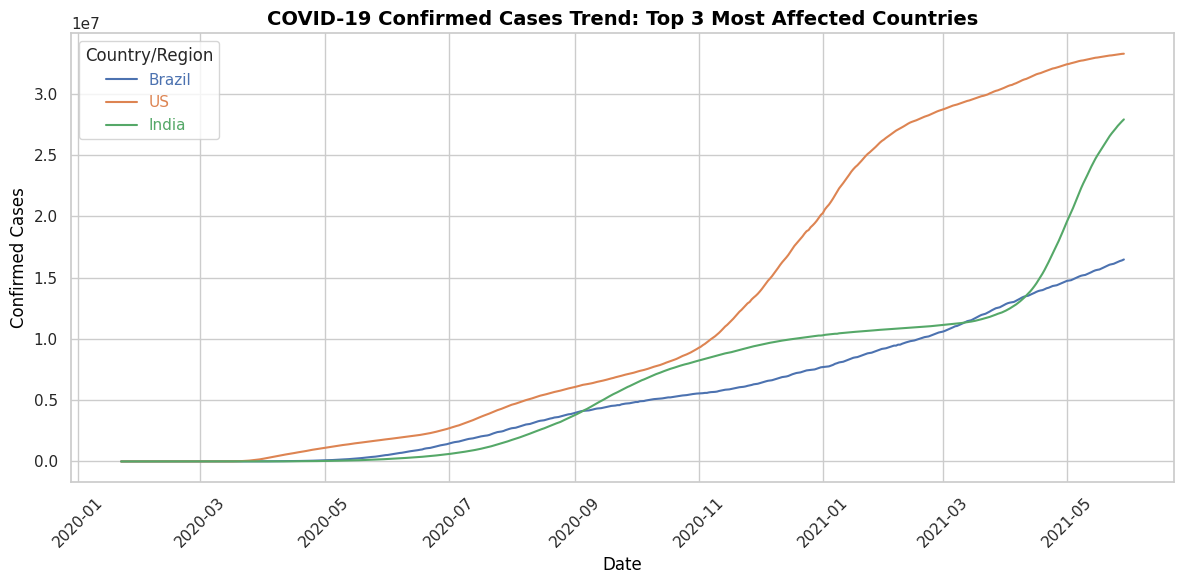

In [19]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(x="Date", y="C_cases", data=top3_countries,hue = "Country/Region",estimator = "sum",errorbar=None,)
plt.title("COVID-19 Confirmed Cases Trend: Top 3 Most Affected Countries",color="black",fontsize=14,fontweight="bold")
plt.xlabel("Date",fontsize=12,color="black")
plt.ylabel("Confirmed Cases",fontsize=12,color="black")
plt.xticks(rotation=45,)
plt.legend(title="Country/Region",labelcolor="linecolor")
plt.tight_layout()
plt.show()



**Key Insights:**

• US, India, and Brazil recorded the highest cumulative confirmed case totals among the countries considered at the latest available date.

• US shows a substantial increase in confirmed cases over the study period, with particularly strong growth during the later stages of 2020 and early 2021.

• India experienced a rapid increase in confirmed cases during 2020, followed by another sharp rise in 2021.

• Brazil also showed sustained growth in confirmed cases, with major increases during successive waves of the pandemic.

### **Confirmed Cases Over Time: China**

The confirmed COVID-19 cases in China are analyzed separately to examine how the reported case count evolved over the study period.

In [20]:
# Boolean Check
df_c["Country/Region"].isin(["China"])

# Boolean Indexing
china_confirmed = df_c[df_c["Country/Region"].isin(["China"])]

In [21]:
china_confirmed.head()

,Province/State,Country/Region,Lat,Long,Date,C_cases
90,Yunnan,China,24.9740,101.4870,2020-01-22,1
89,Xinjiang,China,41.1129,85.2401,2020-01-22,0
91,Zhejiang,China,29.1832,120.0934,2020-01-22,10
72,Hunan,China,27.6104,111.7088,2020-01-22,4
71,Hubei,China,30.9756,112.2707,2020-01-22,444


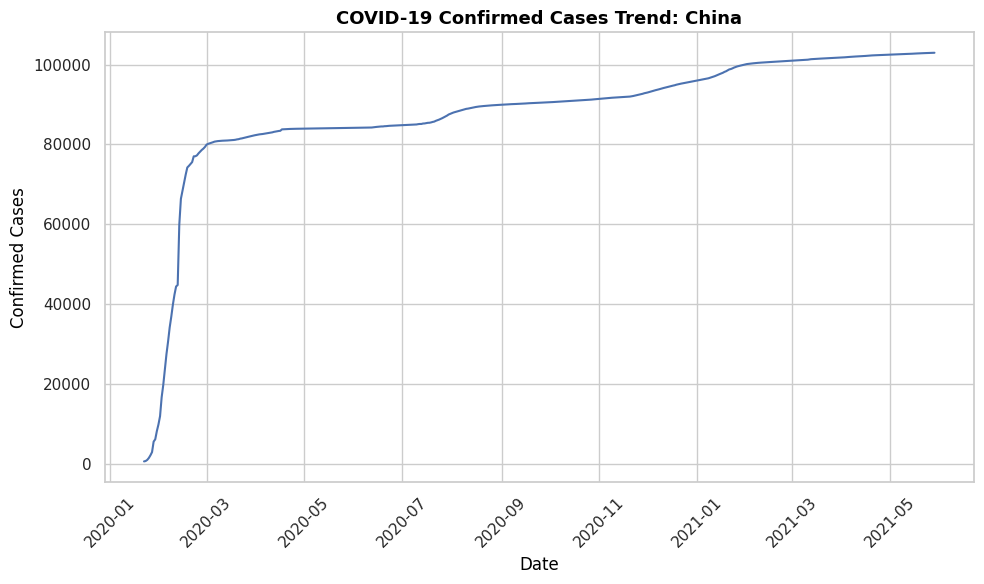

In [22]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(x="Date", y="C_cases", data=china_confirmed,errorbar=None,estimator = "sum")
plt.title("COVID-19 Confirmed Cases Trend: China",color="black",fontsize=13,fontweight="bold")
plt.xlabel("Date",fontsize=12,color="black")
plt.ylabel("Confirmed Cases",fontsize=12,color="black")
plt.xticks(rotation=45,)
plt.tight_layout()
plt.show()

**Key Insights:**

• China experienced a rapid increase in confirmed cases during the initial stage of the pandemic in early 2020.

• After the initial outbreak, the cumulative confirmed case trend became comparatively flatter, indicating slower growth in reported cases for much of the remaining study period.

• The pattern differs from the sustained increases observed in several countries with later major waves of COVID-19.

In [23]:
# Select the three countries
peak_cases = df_c[df_c["Country/Region"].isin(["Germany", "France", "Italy"])].copy()

# Combine multiple rows for the same country on the same date
peak_cases = peak_cases.groupby(["Country/Region", "Date"], as_index=False)["C_cases"].sum()

# Sort by country and date
peak_cases = peak_cases.sort_values(["Country/Region", "Date"])

# Calculate daily new cases
peak_cases["Actual_cases"] = peak_cases.groupby("Country/Region")["C_cases"].diff()

peak_cases["Plot_cases"] = peak_cases["Actual_cases"].clip(lower=0)



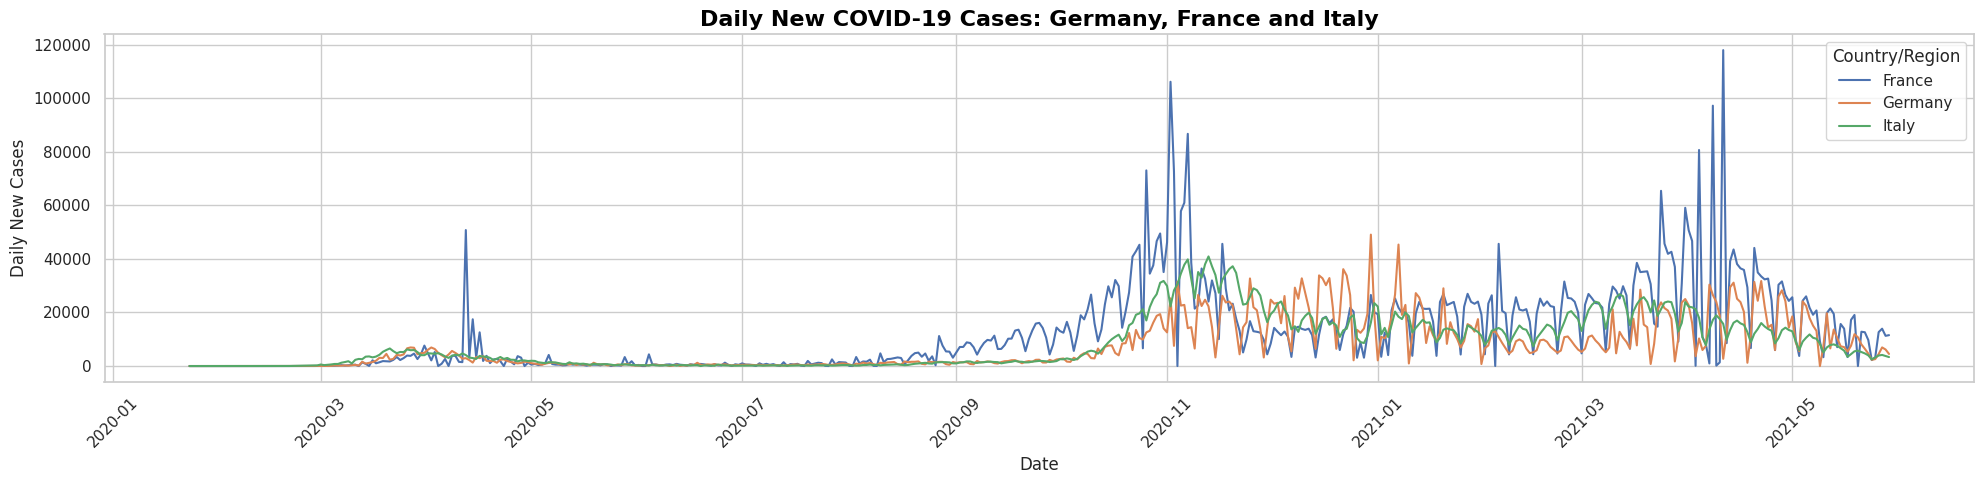

In [24]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(20, 5))

sns.lineplot(data=peak_cases,x="Date",y="Plot_cases",hue="Country/Region",errorbar=None)

plt.title("Daily New COVID-19 Cases: Germany, France and Italy",color="black",fontsize=16,fontweight="bold")

plt.xlabel("Date")
plt.ylabel("Daily New Cases")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## **Highest Single-Day Surge**

The following output identifies the country with the highest single-day increase in confirmed COVID-19 cases among Germany, France, and Italy, along with the date on which the surge occurred.

In [25]:
peak_cases.loc[peak_cases["Actual_cases"].idxmax()]

,445
Country/Region,France
Date,2021-04-11 00:00:00
C_cases,5119585
Actual_cases,117900.0
Plot_cases,117900.0


# **Recovery Rate Comparison: Canada vs Australia**

The recovery rate is calculated as the percentage of confirmed cases that were recorded as recovered as of December 31, 2020.

This comparison helps assess the reported recovery outcomes for Canada and Australia based on the available dataset.

In [26]:
r.head(3)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,87902,88066,88208,88346,88497,88672,88861,89040,89232,89419


In [27]:

date_columns = r.columns[4:]

correct_dates = pd.date_range(start="2020-01-22",periods=len(date_columns),freq="D")

# Rename the date columns
r.columns = (list(r.columns[:4]) +list(correct_dates))

In [28]:
df_r = pd.melt(r,id_vars=["Province/State", "Country/Region", "Lat", "Long"],var_name="Date",value_name="R_cases")

In [29]:
df_r.head(3)

,Province/State,Country/Region,Lat,Long,Date,R_cases
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22 00:00:00,0.0
1,NaN,Albania,41.15330,20.168300,2020-01-22 00:00:00,0.0
2,NaN,Algeria,28.03390,1.659600,2020-01-22 00:00:00,0.0


In [30]:
df_r.shape

(128934, 6)

In [31]:
df_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128934 entries, 0 to 128933
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Province/State  34580 non-null   object 
 1   Country/Region  128934 non-null  object 
 2   Lat             128440 non-null  float64
 3   Long            128440 non-null  float64
 4   Date            128934 non-null  object 
 5   R_cases         128933 non-null  float64
dtypes: float64(3), object(3)
memory usage: 5.9+ MB


In [32]:
df_r["Date"] = pd.to_datetime(df_r["Date"])

In [33]:
df_r = df_r.sort_values(by=["Country/Region","Date"])

In [34]:
df_r["Province/State"] = df_r["Province/State"].fillna("All Provinces")

In [35]:
confirmed = df_c[(df_c["Country/Region"].isin(["Canada","Australia"])) & (df_c['Date'] == "2020-12-31")].copy()

In [36]:
recovered = df_r[(df_r["Country/Region"].isin(["Canada","Australia"])) & (df_r['Date'] == "2020-12-31")].copy()

In [37]:
confirmed_total =  confirmed.groupby("Country/Region",as_index = False)["C_cases"].sum()

In [38]:
confirmed_total

,Country/Region,C_cases
0,Australia,28425
1,Canada,584409


In [39]:
recovered_total = recovered.groupby("Country/Region",as_index = False)["R_cases"].sum()

In [40]:
recovered_total

,Country/Region,R_cases
0,Australia,22565.0
1,Canada,493638.0


In [41]:
recovery_rate = pd.merge(confirmed_total,recovered_total,on = "Country/Region",how="inner")

In [42]:
recovery_rate

,Country/Region,C_cases,R_cases
0,Australia,28425,22565.0
1,Canada,584409,493638.0


In [43]:
recovery_rate["Recovery_rate(%)"] = recovery_rate["R_cases"] / recovery_rate["C_cases"]*100

In [44]:
recovery_rate.sort_values(by="Recovery_rate(%)",ascending=False)

,Country/Region,C_cases,R_cases,Recovery_rate(%)
1,Canada,584409,493638.0,84.467898
0,Australia,28425,22565.0,79.384345


**Key Finding**

Canada recorded the higher recovery rate at approximately **84.47%**, compared with approximately **79.38%** for Australia as of December 31, 2020.

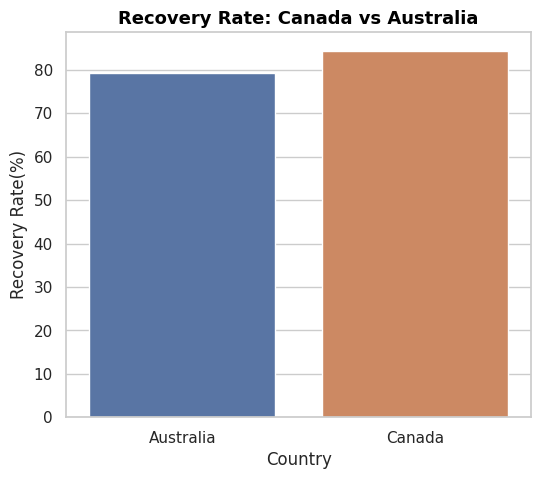

In [45]:
plt.figure(figsize=(6, 5))
sns.barplot(data=recovery_rate,x="Country/Region",y="Recovery_rate(%)",hue="Country/Region",errorbar=None)
plt.title("Recovery Rate: Canada vs Australia",color="black",fontsize=13,fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Recovery Rate(%)")
plt.show()

**Key Insights:**

Based on the recovery-rate metric used in this analysis, **Canada** showed a higher recorded recovery rate than Australia as of December 31, 2020.

However, recovery rate alone is not sufficient to determine which country managed the pandemic better overall, as it can be affected by testing, reporting practices, and the timing of recoveries.

# **Death Rate Distribution Among Canadian Provinces**

The death rate is calculated for each province/territory in Canada as the percentage of confirmed cases that resulted in reported deaths, using the data available as of May 29, 2021.

In [46]:
d.head(3)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,3401,3405,3411,3418,3426,3433,3440,3448,3455,3460


In [47]:
date_columns = d.columns[4:]

correct_dates = pd.date_range(start="2020-01-22",periods=len(date_columns),freq="D")

# Rename the date columns
d.columns = list(d.columns[:4]) +list(correct_dates)

In [48]:
df_d = d.melt(id_vars=["Province/State", "Country/Region", "Lat", "Long"],var_name="Date",value_name="D_cases")

In [49]:
df_d.head(3)

,Province/State,Country/Region,Lat,Long,Date,D_cases
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22 00:00:00,0.0
1,NaN,Albania,41.15330,20.168300,2020-01-22 00:00:00,0.0
2,NaN,Algeria,28.03390,1.659600,2020-01-22 00:00:00,0.0


In [50]:
df_d["Date"] = pd.to_datetime(df_d["Date"])

In [51]:
df_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136344 entries, 0 to 136343
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Province/State  42484 non-null   object        
 1   Country/Region  136344 non-null  object        
 2   Lat             135356 non-null  float64       
 3   Long            135356 non-null  float64       
 4   Date            136344 non-null  datetime64[ns]
 5   D_cases         136343 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 6.2+ MB


In [52]:
canada_c = df_c[(df_c["Country/Region"] == "Canada") & (df_c["Date"] == "2021-05-29")].copy()[["Province/State","Country/Region","C_cases"]]

In [53]:
canada_c.head(3)

,Province/State,Country/Region,C_cases
136118,Prince Edward Island,Canada,200
136122,Yukon,Canada,84
136116,Nunavut,Canada,648


In [54]:
canada_d = df_d[(df_d["Country/Region"] == "Canada") & (df_d["Date"] == "2021-05-29")].copy()[["Province/State","Country/Region","D_cases"]]

In [55]:
canada_d.head(3)

,Province/State,Country/Region,D_cases
136107,Alberta,Canada,2214.0
136108,British Columbia,Canada,1692.0
136109,Diamond Princess,Canada,1.0


In [56]:
death_rate = pd.merge(canada_c,canada_d,on=["Province/State","Country/Region"],how="inner")

In [57]:
death_rate["Death_rate(%)"] = death_rate["D_cases"] / death_rate["C_cases"]*100

In [58]:
death_rate = death_rate[death_rate["C_cases"] > 0].copy()

In [59]:
death_rate = death_rate.sort_values(by="Death_rate(%)",ascending=False)

In [60]:
death_rate.head(1)


,Province/State,Country/Region,C_cases,D_cases,Death_rate(%)
10,Quebec,Canada,369728,11125.0,3.008969


**Highest Death Rate**

**Quebec** recorded the highest reported death rate among the Canadian provinces/territories in the dataset as of May 29, 2021.

In [61]:
death_rate.tail()

,Province/State,Country/Region,C_cases,D_cases,Death_rate(%)
13,Newfoundland and Labrador,Canada,1302,6.0,0.460829
0,Prince Edward Island,Canada,200,0.0,0.000000
9,Grand Princess,Canada,13,0.0,0.000000
11,Repatriated Travellers,Canada,13,0.0,0.000000
14,Northwest Territories,Canada,127,0.0,0.000000


**Lowest Death Rate**

**Prince Edward Island** and **Northwest Territories** recorded the lowest reported death rate in the dataset as of May 29, 2021.

# **Total Deaths Reported by Countries**

The following analysis calculates the total number of reported COVID-19 deaths for each country as of the latest available date in the dataset.

In [62]:
total_deaths = df_d[df_d['Date'] == df_d['Date'].max()].groupby("Country/Region")["D_cases"].sum().sort_values(ascending=False).reset_index()

In [63]:
total_deaths.head()

,Country/Region,D_cases
0,US,594306.0
1,Brazil,461057.0
2,India,325972.0
3,Mexico,223455.0
4,United Kingdom,128037.0


In [64]:
df_d = df_d.sort_values(by=["Country/Region","Date"])

In [65]:
df_d["Daily_deaths"] = df_d.groupby(["Country/Region"])["D_cases"].diff()

In [66]:
avg_daily_deaths = df_d.groupby("Country/Region")["Daily_deaths"].mean().sort_values(ascending=False).reset_index()

In [67]:
top5_avg_daily_deaths = avg_daily_deaths.head()

### **Top 5 Countries by Average Daily Deaths**

The following analysis calculates the average number of daily new deaths for each country and identifies the five countries with the highest average daily deaths.

In [68]:
top5_avg_daily_deaths

,Country/Region,Daily_deaths
0,US,1205.488844
1,Brazil,935.206897
2,India,661.200811
3,Mexico,453.255578
4,Italy,255.582150


### **US Total Deaths Evolution Over Time**

The following analysis examines how the cumulative number of reported COVID-19 deaths in the United States changed over time.

Since the dataset contains separate rows for different provinces/states, the death counts are aggregated by date to obtain the total number of deaths reported across the United States.

In [69]:
us_deaths = df_d[df_d["Country/Region"] == "US"].copy()

In [70]:
us_deaths = us_deaths.groupby("Date",as_index=False)["D_cases"].sum()

In [71]:
us_deaths = us_deaths.sort_values("Date")

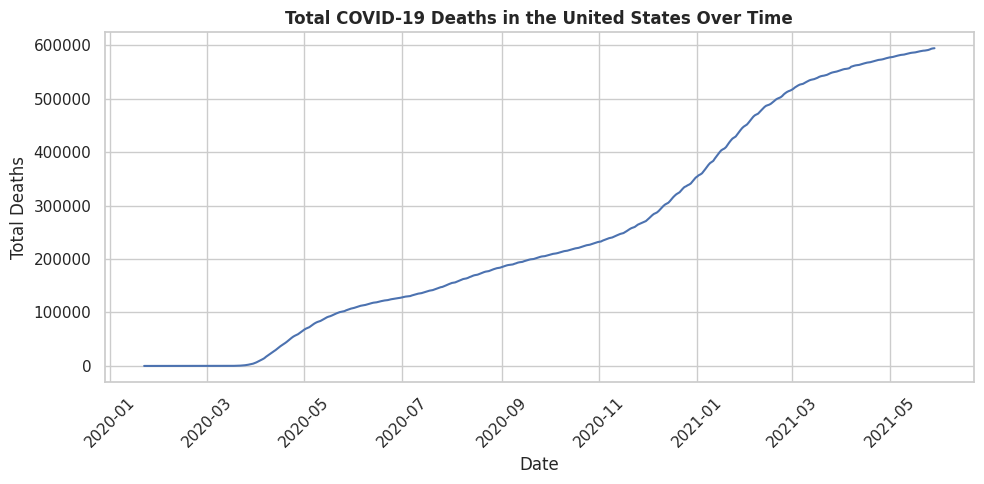

In [72]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=us_deaths,x="Date",y="D_cases",errorbar=None)
plt.title("Total COVID-19 Deaths in the United States Over Time",fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Total Deaths")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Key Insights:**

- Deaths remained very low during the initial months of 2020.
- A sharp increase in cumulative deaths occurred from March to May 2020.
- Deaths continued to rise through mid-2020 at a relatively slower pace.
- A much steeper increase occurred during late 2020 and early 2021, with the curve particularly steep around January–February 2021.
- By May 2021, cumulative deaths reached approximately 590,000 in the dataset.




### **Merging COVID-19 Datasets**

The confirmed cases, deaths, and recoveries datasets are first aggregated by `Country/Region` and `Date`.

The three datasets are then merged using `Country/Region` and `Date` as the common keys to create a comprehensive dataset containing confirmed cases, deaths, and recoveries for each country and date.

Aggregating before merging helps avoid duplicate records caused by multiple province/state-level entries within the same country.

In [73]:
confirmed_countries = df_c.groupby(["Country/Region","Date"],as_index=False)["C_cases"].sum()

In [74]:
recovered_countries = df_r.groupby(["Country/Region","Date"],as_index=False)["R_cases"].sum()

In [75]:
deaths_countries = df_d.groupby(["Country/Region","Date"],as_index=False)["D_cases"].sum()

In [76]:
merged_data = pd.merge(confirmed_countries,deaths_countries,on=["Country/Region","Date"],how="inner")

In [77]:
merged_data = pd.merge(merged_data,recovered_countries,on=["Country/Region","Date"],how="inner")

In [78]:
merged_data.head(3)

,Country/Region,Date,C_cases,D_cases,R_cases
0,Afghanistan,2020-01-22,0,0.0,0.0
1,Afghanistan,2020-01-23,0,0.0,0.0
2,Afghanistan,2020-01-24,0,0.0,0.0


### **Monthly COVID-19 Case Analysis**

The daily changes in confirmed cases, deaths, and recoveries are aggregated by month for each country.

This monthly aggregation helps us understand how the pandemic progressed over time and identify major waves or changes in reported cases, deaths, and recoveries.

In [79]:
merged_data.sort_values(by=["Country/Region", "Date"],inplace=True)

merged_data["new_confirmed"] = merged_data.groupby("Country/Region")["C_cases"].diff()

merged_data["new_recovered"] = merged_data.groupby("Country/Region")["R_cases"].diff()

merged_data["new_deaths"] = merged_data.groupby("Country/Region")["D_cases"].diff()

In [80]:
merged_data["Month"] = merged_data["Date"].dt.to_period("M")

In [81]:
monthly_data = merged_data.groupby(["Country/Region","Month"],as_index=False)[["new_confirmed","new_deaths","new_recovered"]].sum()

### **Monthly Comparison: US, Italy, and Brazil**

The monthly COVID-19 trends are compared for the United States, Italy, and Brazil to examine differences in confirmed cases, deaths, and recoveries across these countries.

In [82]:
selected_countries = monthly_data[monthly_data["Country/Region"].isin(["US","Italy","Brazil"])].copy()

In [83]:
selected_countries["Month"] = selected_countries["Month"].dt.to_timestamp()

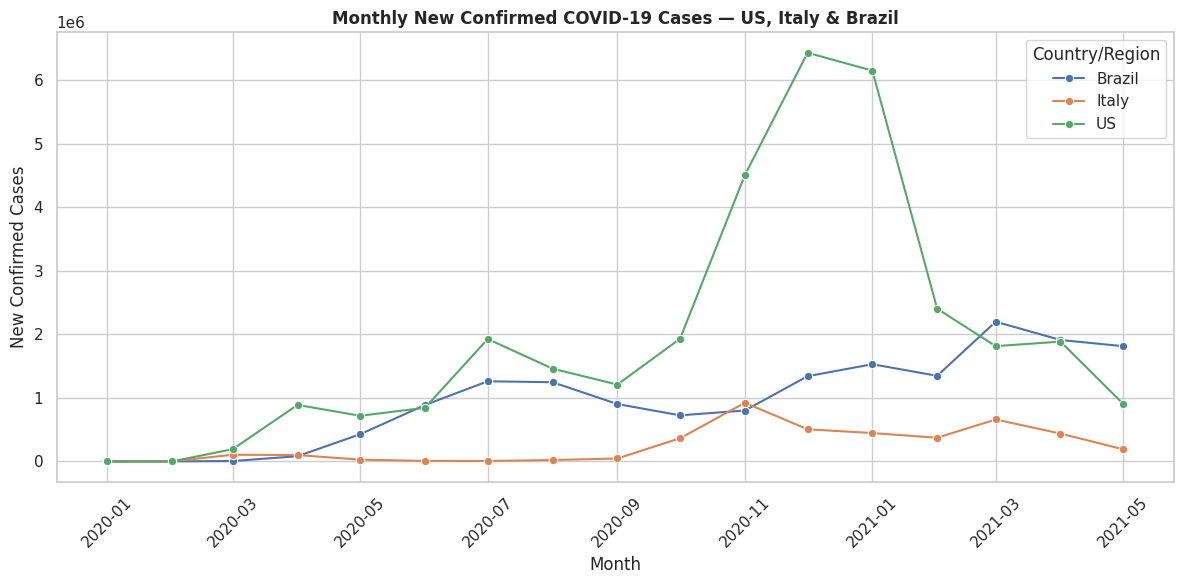

In [84]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=selected_countries,x="Month",y="new_confirmed",hue="Country/Region",marker="o",errorbar=None)
plt.title("Monthly New Confirmed COVID-19 Cases — US, Italy & Brazil",fontweight="bold")
plt.xlabel("Month")
plt.ylabel("New Confirmed Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Key Insights:**

**• US:** Experienced its largest surge during late 2020, with cases reaching their highest levels around December 2020 and January 2021.

**• Brazil:** Cases increased substantially during the second half of 2020, with a major peak around March 2021.

**• Italy:** Experienced an early major wave around March–April 2020, followed by another significant wave toward the end of 2020.

**•** The three countries experienced their major infection waves at different times.

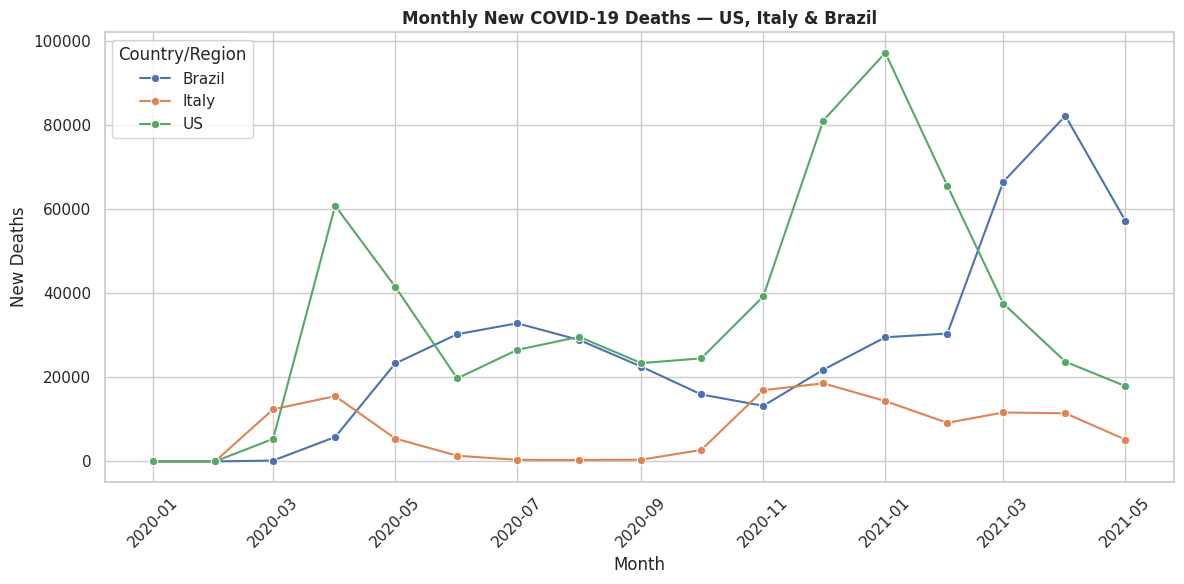

In [85]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=selected_countries,x="Month",y="new_deaths",hue="Country/Region",marker="o",errorbar=None)
plt.title("Monthly New COVID-19 Deaths — US, Italy & Brazil", fontweight="bold")
plt.xlabel("Month")
plt.ylabel("New Deaths")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Key Insights:**

**• US:** Recorded a major increase in deaths around April 2020, followed by a much larger mortality wave around December 2020–January 2021.

**• Brazil:** Experienced a particularly large increase in deaths during early 2021, reaching its highest levels around April 2021.

**• Italy:** Experienced its first major mortality wave around March–April 2020, followed by another increase during late 2020.

• The mortality trends generally correspond with major infection waves, although the peaks do not always occur in the same month.

In [86]:
recovery_countries = selected_countries[selected_countries["Country/Region"].isin(["Brazil", "Italy"])].copy()

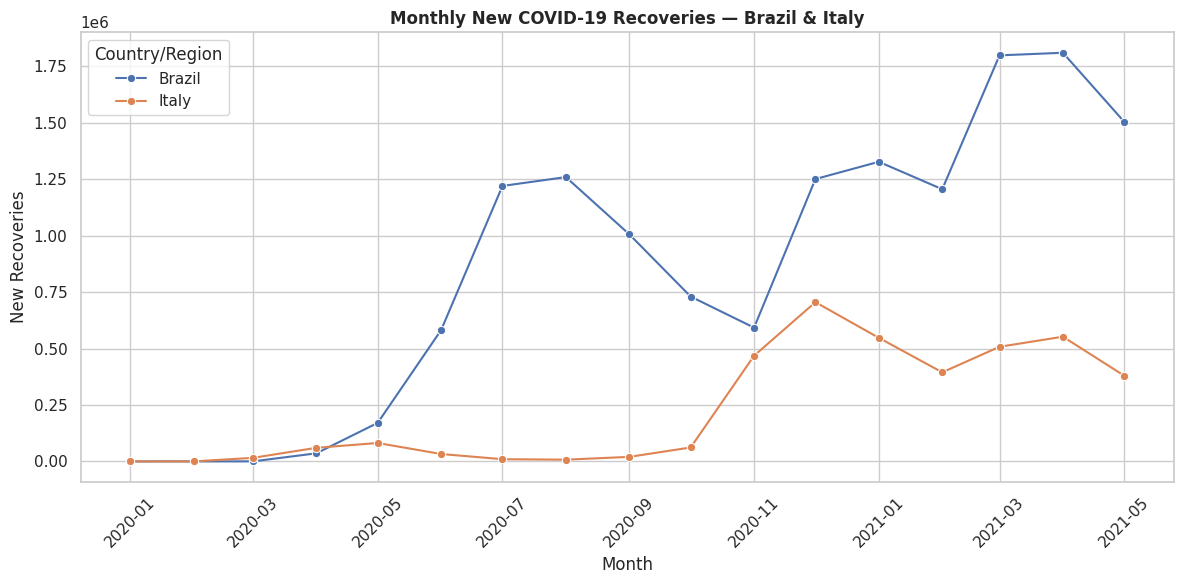

In [87]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=recovery_countries,x="Month",y="new_recovered",hue="Country/Region",marker="o",errorbar=None)
plt.title("Monthly New COVID-19 Recoveries — Brazil & Italy",fontweight="bold")
plt.xlabel("Month")
plt.ylabel("New Recoveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Note:** The recovery data for the US contains a significant reporting discontinuity, resulting in negative calculated monthly recoveries. Therefore, the US recovery trend has been excluded from this visualization to avoid misleading interpretation.

**Key Insights:**

**• Brazil:** Recorded considerably more monthly recoveries than Italy throughout most of the period.

**• Brazil:** Recoveries increased substantially around June–July 2020 and again during early 2021, reaching around 1.8 million monthly recoveries during March–April 2021.

**• Italy:** Had relatively low recovery numbers during the first half of 2020, followed by a significant increase from late 2020 onward.

### **Top 3 Countries by Average COVID-19 Death Rate Through 2020**

The average death rate is calculated using the reported cumulative deaths and confirmed cases for each country through December 31, 2020.

The analysis identifies the three countries with the highest average reported death rates and provides a basis for interpreting differences in reported COVID-19 outcomes.

In [88]:
data_2020 = merged_data[(merged_data["Date"] <= "2020-12-31") & merged_data["C_cases"]>0].copy()

In [89]:
data_2020["Death_rate"] = data_2020["D_cases"]/data_2020["C_cases"]*100

In [90]:
avg_death_rate = data_2020.groupby("Country/Region")["Death_rate"].mean().sort_values(ascending=False).reset_index()

In [91]:
avg_death_rate = avg_death_rate[avg_death_rate["Country/Region"] != "MS Zaandam"].copy()

In [92]:
top_3_death_rates = avg_death_rate.head(3)

In [93]:
top_3_death_rates


,Country/Region,Death_rate
0,Yemen,23.764993
2,Sudan,13.638977
3,Italy,9.309240


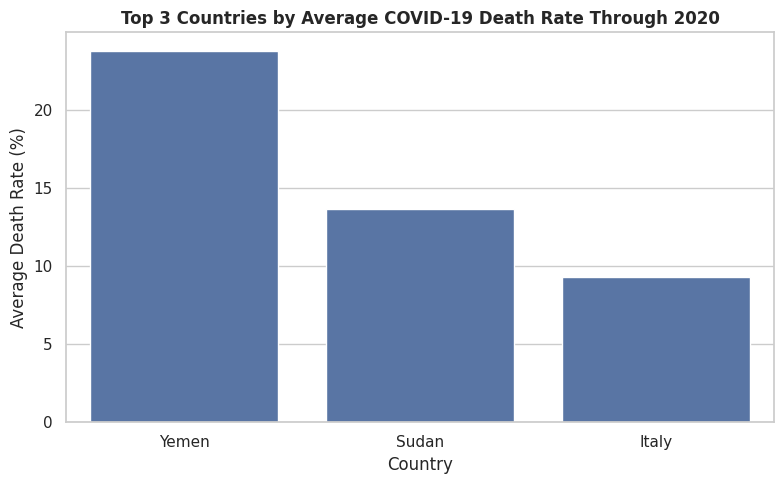

In [94]:
plt.figure(figsize=(8, 5))
sns.barplot(data=top_3_death_rates,x="Country/Region",y="Death_rate",errorbar=None)
plt.title("Top 3 Countries by Average COVID-19 Death Rate Through 2020",fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Average Death Rate (%)")
plt.tight_layout()
plt.show()

**Key Insights:**

• **Yemen** recorded the highest average death rate during 2020, at approximately **23.76%**.

• **Sudan** ranked second during 2020, with an average death rate of approximately **13.64%**.

• **Italy** ranked third during 2020, with an average death rate of approximately 9.**31%**.

• These relatively high death rates indicate that, during 2020, these countries recorded comparatively high numbers of deaths relative to their confirmed cases.

• However, **death rate based on confirmed cases should not be interpreted as the true infection fatality rate**, because confirmed cases depend heavily on testing and reporting practices.

### **South Africa: Total Recoveries vs Deaths**

The following analysis compares the total reported COVID-19 recoveries and deaths in South Africa as of the latest available date in the dataset.

In [95]:
south_africa = merged_data[(merged_data["Country/Region"]=="South Africa") & (merged_data["Date"] == merged_data["Date"].max())].copy()

In [96]:
south_africa

,Country/Region,Date,C_cases,D_cases,R_cases,new_confirmed,new_recovered,new_deaths,Month
80027,South Africa,2021-05-29,1659070,56363.0,1554184.0,4519.0,2664.0,70.0,2021-05


In [97]:
south_africa_totals = south_africa[["Country/Region","R_cases","D_cases"]]

In [98]:
south_africa_totals

,Country/Region,R_cases,D_cases
80027,South Africa,1554184.0,56363.0


**Key Insights:**

• **South Africa** recorded **1,554,184** recoveries and **56,363** deaths as of 29 May 2021.

• The number of recoveries was substantially higher than the number of deaths.

• This indicates that the majority of recorded outcomes in the dataset were recoveries rather than deaths.

• However, recoveries and deaths alone should not be used as a complete measure of pandemic management, as they depend on case detection and reporting practices.

### **US Monthly Recovery Ratio**

The monthly recovery ratio for the United States is calculated as the percentage of newly reported recoveries relative to newly confirmed cases from March 2020 to May 2021.

This analysis helps identify the month with the highest reported recovery ratio and observe how the ratio changed over the study period.

In [99]:
us_recovery = monthly_data[(monthly_data["Country/Region"]=="US") & (monthly_data["Month"] >= "2020-03") & (monthly_data["Month"] <= "2021-05") ].copy()

In [100]:
us_recovery["Recovery_ratio"] = us_recovery["new_recovered"]/us_recovery["new_confirmed"]*100

In [101]:
us_recovery["Month"] = us_recovery["Month"].dt.to_timestamp()

In [102]:
us_recovery

,Country/Region,Month,new_confirmed,new_deaths,new_recovered,Recovery_ratio
3045,US,2020-03-01,192276.0,5369.0,7017.0,3.649441
3046,US,2020-04-01,888719.0,60865.0,146923.0,16.531997
3047,US,2020-05-01,717698.0,41605.0,290811.0,40.519968
3048,US,2020-06-01,843456.0,19767.0,275873.0,32.707456
3049,US,2020-07-01,1925246.0,26550.0,717529.0,37.269471
3050,US,2020-08-01,1459475.0,29661.0,746665.0,51.159835
3051,US,2020-09-01,1208533.0,23399.0,655863.0,54.269350
3052,US,2020-10-01,1930191.0,24532.0,771790.0,39.985162
3053,US,2020-11-01,4504713.0,39271.0,1533841.0,34.049694
3054,US,2020-12-01,6429031.0,81143.0,-5146319.0,-80.048129


In [103]:
valid_recovery = us_recovery[us_recovery["Recovery_ratio"] > 0].copy()

In [104]:
valid_recovery = valid_recovery.sort_values(by="Recovery_ratio",ascending = False)

In [105]:
valid_recovery.head(1)

,Country/Region,Month,new_confirmed,new_deaths,new_recovered,Recovery_ratio
3051,US,2020-09-01,1208533.0,23399.0,655863.0,54.26935


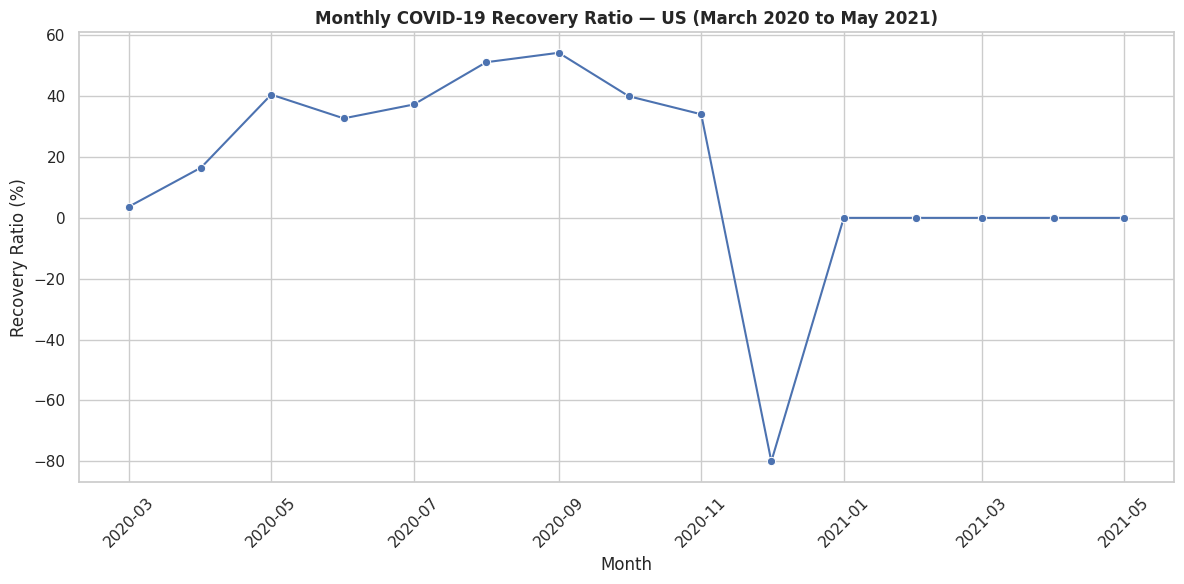

In [106]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=us_recovery,x="Month",y="Recovery_ratio",marker="o",errorbar=None)
plt.title("Monthly COVID-19 Recovery Ratio — US (March 2020 to May 2021)",fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Recovery Ratio (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Key Insights:**

• The **US** recorded its highest monthly recovery ratio in September 2020, at approximately **54.27%**.

• The recovery ratio increased substantially from March to September 2020, reaching its peak as the number of recorded recoveries increased relative to newly confirmed cases.

• After September 2020, the recovery ratio declined through November 2020, reaching approximately **34.05%**.

• The sharp negative value in December 2020 is a data **reporting discontinuity**, rather than a real-world negative recovery rate.

• From January to May 2021, the dataset records zero new recoveries for the US, so these months should not be interpreted as an actual 0% recovery ratio.